# 📊 Análise da Copa do Mundo de 2026 com Machine Learning

Este notebook analisa seleções da primeira fase da Copa do Mundo de 2026 usando técnicas de ciência de dados.

O objetivo é responder quatro perguntas:

- Quais seleções têm perfis estatísticos semelhantes?
- Como os grupos de desempenho se organizam visualmente?
- Quais equipes são mais parecidas entre si?
- Quais indicadores ajudam a prever a classificação para a fase eliminatória?

## 🧰 Bibliotecas

Importamos bibliotecas para manipulação dos dados, visualização, clusterização, rede de similaridade e predição.

In [12]:
# Bibliotecas

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go
import networkx as nx

from matplotlib.patches import Ellipse
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, classification_report, confusion_matrix
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

# Rótulos mais bonitos no gráfico PCA
try:
    from adjustText import adjust_text
except Exception:
    try:
        !pip -q install adjustText
        from adjustText import adjust_text
    except Exception:
        adjust_text = None

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", lambda x: f"{x:.3f}")

plt.rcParams["figure.figsize"] = (12, 7)
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.25

## 📂 Carregamento da base

A análise usa a aba `Tabelao_Primeira_Fase`, que consolida uma linha por seleção com métricas de resultado, xG, ranking FIFA e desempenho ajustado.

In [13]:
# Carregamento da base

arquivo = "copa_2026_xg_primeira_fase.xlsx"
aba = "Tabelao_Primeira_Fase"

df = pd.read_excel(arquivo, sheet_name=aba)

print(f"Base: {aba}")
print(f"Dimensão: {df.shape[0]} linhas × {df.shape[1]} colunas")
print(f"Valores ausentes: {df.isna().sum().sum()}")

display(df.head())

Base: Tabelao_Primeira_Fase
Dimensão: 48 linhas × 59 colunas
Valores ausentes: 6


,Selecao,Grupo,Posicao_Grupo,Classificado_Flag,Classificado,Jogos,V,E,D,Pontos,GF,GA,Saldo_Real,GF_Jogo,GA_Jogo,xG_Jogo,xGA_Jogo,xGD_Jogo,xG_Total,xGA_Total,xGD_Total,GF_menos_xG,GF_sobre_xG,GF_var_pct_xG,GA_menos_xGA,GA_sobre_xGA,GA_var_pct_xGA,Saldo_real_menos_xGD,Indice_resultado_sobre_xGD,FIFA_Rank,FIFA_Pontos,Media_FIFA_Adversarios,Dif_Selecao_Adversarios,xGD_Esperado_Pre_Copa,xGD_Acima_Esperado,Score_Ajustado,Ranking_Score_Ajustado,Dificuldade_Cod,Dificuldade_Texto,Maior_GF_Jogo,Pct_GF_Maior_Jogo,Maior_GA_Jogo,Pct_GA_Maior_Jogo,Mediana_GF,Mediana_GA,Desvio_GF,CV_GF,Desvio_GA,CV_GA,Mediana_Saldo,xG_Jogo_A_Jogo_Disponivel_Flag,Diag_Ofensivo,Diag_Defensivo,Diag_Resultado,Diag_Variancia,Leitura_Curta,Fonte_xG,Fonte_Resultados,Fonte_Ranking
0,Mexico,A,1,1,Sim,3,3,0,0,9,6,0,6,2.000,0.000,1.230,0.880,0.350,3.690,2.640,1.050,2.310,162.6%,62.6%,-2.640,0.0%,-100.0%,4.950,571.4%,14,1687.480,1508.580,178.900,0.630,-0.280,0.460,17,3,Medio,3,50.0%,0,NaN,2.000,0.000,0.820,40.8%,0.000,NaN,2.000,0,Converteu muito acima,Sofreu muito menos que xGA,Realizado muito melhor que processo,Alta variancia/concentracao,Converteu muito acima; Sofreu muito menos que ...,https://footystats.org/international/world-cup/xg,https://www.sbnation.com/soccer/1117905/world-...,https://www.whereig.com/football/fifa-world-ra...
1,South Africa,A,2,1,Sim,3,1,1,1,4,2,3,-1,0.670,1.000,1.150,1.400,-0.250,3.450,4.200,-0.750,-1.450,58.0%,-42.0%,-1.200,71.4%,-28.6%,-0.250,133.3%,60,1428.380,1594.950,-166.570,-0.580,0.330,-0.380,33,4,Dificil,1,50.0%,2,66.7%,1.000,1.000,0.470,70.7%,0.820,81.6%,0.000,0,Subconverteu muito,Sofreu menos que xGA,Passou acima do processo,Alta variancia/concentracao,Subconverteu muito; Sofreu menos que xGA; Pass...,https://footystats.org/international/world-cup/xg,https://www.sbnation.com/soccer/1117905/world-...,https://www.whereig.com/football/fifa-world-ra...
2,South Korea,A,3,0,Nao,3,1,0,2,3,2,3,-1,0.670,1.000,1.350,1.070,0.280,4.050,3.210,0.840,-2.050,49.4%,-50.6%,-0.210,93.5%,-6.5%,-1.840,-119.0%,25,1591.630,1540.530,51.100,0.180,0.100,0.240,20,3,Medio,2,100.0%,1,33.3%,0.000,1.000,0.940,141.4%,0.000,0.0%,-1.000,0,Subconverteu muito,Dentro do esperado,Caiu apesar de bom processo,Alta variancia/concentracao,Subconverteu muito; Dentro do esperado; Caiu a...,https://footystats.org/international/world-cup/xg,https://www.sbnation.com/soccer/1117905/world-...,https://www.whereig.com/football/fifa-world-ra...
3,Czechia,A,4,0,Nao,3,0,1,2,1,2,6,-4,0.670,2.000,1.150,1.520,-0.370,3.450,4.560,-1.110,-1.450,58.0%,-42.0%,1.440,131.6%,31.6%,-2.890,360.4%,40,1505.740,1569.160,-63.420,-0.220,-0.150,-0.310,31,4,Dificil,1,50.0%,3,50.0%,1.000,2.000,0.470,70.7%,0.820,40.8%,-1.000,0,Subconverteu muito,Sofreu muito acima do xGA,Realizado muito pior que processo,Variancia moderada/baixa,Subconverteu muito; Sofreu muito acima do xGA;...,https://footystats.org/international/world-cup/xg,https://www.sbnation.com/soccer/1117905/world-...,https://www.whereig.com/football/fifa-world-ra...
4,Switzerland,B,1,1,Sim,3,2,1,0,7,7,3,4,2.330,1.000,1.780,1.030,0.750,5.340,3.090,2.250,1.660,131.1%,31.1%,-0.090,97.1%,-2.9%,1.750,177.8%,19,1650.060,1465.670,184.390,0.650,0.100,0.710,11,2,Leve,4,57.1%,1,33.3%,2.000,1.000,1.250,53.5%,0.000,0.0%,1.000,0,Converteu muito acima,Dentro do esperado,Processo e resultado proximos,Variancia moderada/baixa,Converteu muito acima; Dentro do esperado; Pro...,https://footystats.org/international/world-cup/xg,https://www.sbnation.com/soccer/1117905/world-...,https://www.whereig.com/football/fifa-world-ra...


## 🧹 Preparação dos dados

Selecionamos variáveis numéricas que representam ataque, defesa, dominância, força relativa e desempenho ajustado. Variáveis textuais, links e colunas muito redundantes ficam fora da modelagem.

In [14]:
# Seleção e preparação das variáveis

features = [
    "xG_Jogo",
    "xGA_Jogo",
    "xGD_Jogo",
    "GF_Jogo",
    "GA_Jogo",
    "Score_Ajustado",
    "FIFA_Rank",
    "Dif_Selecao_Adversarios"
]

df_modelo = df[["Selecao", "Grupo", "Classificado_Flag", "Classificado"] + features].copy()

df_modelo[features] = df_modelo[features].fillna(df_modelo[features].median())

scaler = StandardScaler()
X = scaler.fit_transform(df_modelo[features])

print(f"Seleções analisadas: {df_modelo.shape[0]}")
print(f"Variáveis usadas no modelo: {len(features)}")
display(df_modelo.head())

Seleções analisadas: 48
Variáveis usadas no modelo: 8


,Selecao,Grupo,Classificado_Flag,Classificado,xG_Jogo,xGA_Jogo,xGD_Jogo,GF_Jogo,GA_Jogo,Score_Ajustado,FIFA_Rank,Dif_Selecao_Adversarios
0,Mexico,A,1,Sim,1.230,0.880,0.350,2.000,0.000,0.460,14,178.900
1,South Africa,A,1,Sim,1.150,1.400,-0.250,0.670,1.000,-0.380,60,-166.570
2,South Korea,A,0,Nao,1.350,1.070,0.280,0.670,1.000,0.240,25,51.100
3,Czechia,A,0,Nao,1.150,1.520,-0.370,0.670,2.000,-0.310,40,-63.420
4,Switzerland,B,1,Sim,1.780,1.030,0.750,2.330,1.000,0.710,19,184.390


## 🔎 Relação entre as variáveis

O heatmap ajuda a verificar quais indicadores caminham juntos. Isso é útil para entender redundâncias e interpretar melhor os clusters.

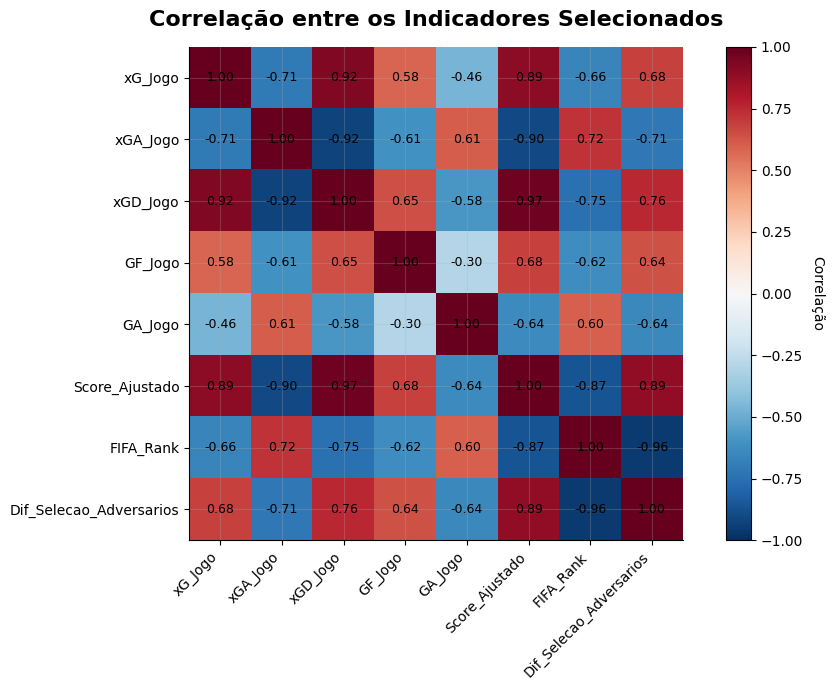

In [15]:
# Heatmap de correlação

corr = df_modelo[features].corr()

fig, ax = plt.subplots(figsize=(10, 7))
im = ax.imshow(corr, cmap="RdBu_r", vmin=-1, vmax=1)

ax.set_xticks(range(len(features)))
ax.set_yticks(range(len(features)))
ax.set_xticklabels(features, rotation=45, ha="right")
ax.set_yticklabels(features)

for i in range(len(features)):
    for j in range(len(features)):
        ax.text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center", fontsize=9)

cbar = plt.colorbar(im, ax=ax)
cbar.set_label("Correlação", rotation=270, labelpad=15)

ax.set_title("Correlação entre os Indicadores Selecionados", fontsize=16, weight="bold", pad=15)
plt.tight_layout()
plt.show()

## 🤖 Escolha do número de clusters

Usamos dois critérios: **inércia** para observar o cotovelo e **Silhouette** para medir a separação entre grupos. O K final deve equilibrar métrica e interpretabilidade.

In [16]:
# Elbow e Silhouette

ks = range(2, 11)
inercia = []
silhouette = []

for k in ks:
    modelo = KMeans(n_clusters=k, random_state=42, n_init=30)
    labels = modelo.fit_predict(X)
    inercia.append(modelo.inertia_)
    silhouette.append(silhouette_score(X, labels))

avaliacao_k = pd.DataFrame({
    "K": list(ks),
    "Inércia": inercia,
    "Silhouette": silhouette
})

display(avaliacao_k)

,K,Inércia,Silhouette
0,2,170.557,0.425
1,3,119.197,0.335
2,4,103.742,0.249
3,5,90.535,0.230
4,6,80.384,0.231
5,7,73.910,0.228
6,8,64.973,0.237
7,9,58.453,0.246
8,10,52.400,0.248


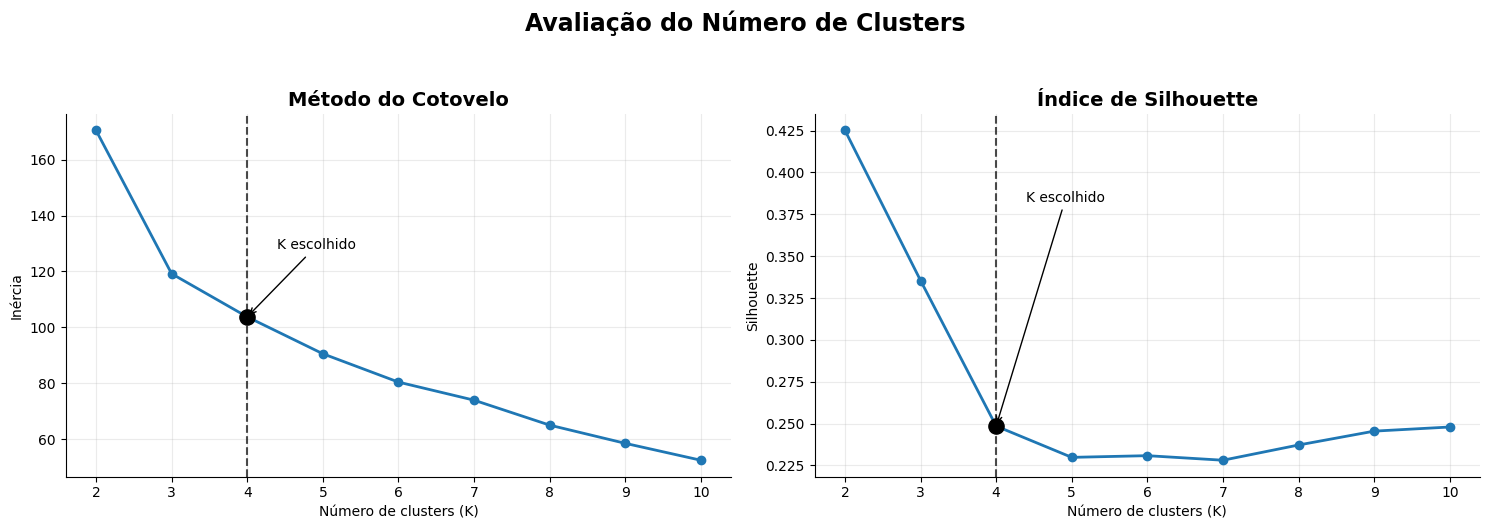

In [17]:
# Gráficos de avaliação do K

k_escolhido = 4

fig, ax = plt.subplots(1, 2, figsize=(15, 5))

ax[0].plot(avaliacao_k["K"], avaliacao_k["Inércia"], marker="o", linewidth=2)
ax[0].axvline(k_escolhido, color="black", linestyle="--", alpha=0.7)
ax[0].scatter(k_escolhido, avaliacao_k.loc[avaliacao_k["K"] == k_escolhido, "Inércia"], s=120, color="black", zorder=5)
ax[0].set_title("Método do Cotovelo", fontsize=14, weight="bold")
ax[0].set_xlabel("Número de clusters (K)")
ax[0].set_ylabel("Inércia")
ax[0].annotate("K escolhido", xy=(k_escolhido, avaliacao_k.loc[avaliacao_k["K"] == k_escolhido, "Inércia"].iloc[0]),
               xytext=(k_escolhido + 0.4, max(inercia)*0.75), arrowprops=dict(arrowstyle="->"))

ax[1].plot(avaliacao_k["K"], avaliacao_k["Silhouette"], marker="o", linewidth=2)
ax[1].axvline(k_escolhido, color="black", linestyle="--", alpha=0.7)
ax[1].scatter(k_escolhido, avaliacao_k.loc[avaliacao_k["K"] == k_escolhido, "Silhouette"], s=120, color="black", zorder=5)
ax[1].set_title("Índice de Silhouette", fontsize=14, weight="bold")
ax[1].set_xlabel("Número de clusters (K)")
ax[1].set_ylabel("Silhouette")
ax[1].annotate("K escolhido", xy=(k_escolhido, avaliacao_k.loc[avaliacao_k["K"] == k_escolhido, "Silhouette"].iloc[0]),
               xytext=(k_escolhido + 0.4, max(silhouette)*0.9), arrowprops=dict(arrowstyle="->"))

plt.suptitle("Avaliação do Número de Clusters", fontsize=17, weight="bold", y=1.05)
plt.tight_layout()
plt.show()

## 🧩 Clusterização final

Embora K=2 tenha forte separação matemática, quatro grupos produzem perfis mais úteis para leitura esportiva: elite, competitivas, intermediárias e baixo desempenho.

In [18]:
# Modelo final de clusterização

kmeans = KMeans(n_clusters=k_escolhido, random_state=42, n_init=30)
df_modelo["Cluster"] = kmeans.fit_predict(X)

# Nomes interpretáveis definidos a partir do perfil médio observado
nomes_clusters = {
    0: "Competitivas",
    1: "Elite",
    2: "Intermediárias",
    3: "Baixo desempenho"
}

df_modelo["Perfil"] = df_modelo["Cluster"].map(nomes_clusters)

perfil_clusters = (
    df_modelo
    .groupby("Perfil")[features]
    .mean()
    .round(2)
    .sort_values("Score_Ajustado", ascending=False)
)

display(perfil_clusters)

,xG_Jogo,xGA_Jogo,xGD_Jogo,GF_Jogo,GA_Jogo,Score_Ajustado,FIFA_Rank,Dif_Selecao_Adversarios
Perfil,,,,,,,,
Elite,1.900,0.980,0.930,2.240,0.850,0.840,11.170,201.890
Intermediárias,1.400,1.300,0.100,1.670,1.470,0.070,26.000,7.070
Competitivas,1.050,1.630,-0.580,0.730,1.150,-0.530,46.730,-129.450
Baixo desempenho,0.870,2.120,-1.260,0.670,3.150,-1.110,64.670,-253.420


In [19]:
# Interpretação dos clusters

print("Quantidade de seleções por perfil")
display(df_modelo["Perfil"].value_counts())

for perfil in perfil_clusters.index:
    print(f"{perfil}")
    display(
        df_modelo.loc[df_modelo["Perfil"] == perfil, ["Selecao", "Grupo", "Classificado", "Score_Ajustado", "xG_Jogo", "xGA_Jogo"]]
        .sort_values("Score_Ajustado", ascending=False)
        .reset_index(drop=True)
    )

Quantidade de seleções por perfil


,count
Perfil,
Elite,18
Competitivas,11
Intermediárias,10
Baixo desempenho,9


Elite


,Selecao,Grupo,Classificado,Score_Ajustado,xG_Jogo,xGA_Jogo
0,Spain,H,Sim,1.510,2.160,0.550
1,Belgium,G,Sim,1.300,2.550,0.980
2,England,L,Sim,1.160,2.120,0.880
3,Canada,B,Sim,1.150,2.390,0.620
4,France,I,Sim,1.150,1.990,0.800
5,Germany,E,Sim,1.070,2.140,0.950
6,Argentina,J,Sim,0.850,1.320,0.740
7,Colombia,K,Sim,0.840,2.020,0.920
8,Morocco,C,Sim,0.810,1.750,0.950
9,Turkey,D,Nao,0.790,2.520,1.250


Intermediárias


,Selecao,Grupo,Classificado,Score_Ajustado,xG_Jogo,xGA_Jogo
0,Ecuador,E,Sim,0.420,1.850,1.320
1,South Korea,A,Nao,0.240,1.350,1.070
2,Sweden,F,Sim,0.190,1.690,1.090
3,Algeria,J,Sim,0.150,1.470,1.110
4,Egypt,G,Sim,0.130,1.630,1.460
5,Japan,F,Sim,0.130,1.140,1.110
6,Croatia,L,Sim,0.020,1.050,1.350
7,Ivory Coast,E,Sim,-0.110,1.270,1.440
8,Austria,J,Sim,-0.160,1.130,1.360
9,Norway,I,Sim,-0.310,1.380,1.640


Competitivas


,Selecao,Grupo,Classificado,Score_Ajustado,xG_Jogo,xGA_Jogo
0,Panama,L,Nao,-0.150,1.180,1.220
1,Iran,G,Nao,-0.260,1.320,1.970
2,Czechia,A,Nao,-0.310,1.150,1.520
3,DR Congo,K,Sim,-0.320,1.140,1.280
4,South Africa,A,Sim,-0.380,1.150,1.400
5,Australia,D,Sim,-0.390,1.100,1.720
6,Scotland,C,Nao,-0.480,1.060,1.630
7,Bosnia and Herzegovina,B,Sim,-0.500,1.040,1.490
8,Cape Verde,H,Sim,-0.960,1.050,1.980
9,Ghana,L,Sim,-1.020,0.590,1.480


Baixo desempenho


,Selecao,Grupo,Classificado,Score_Ajustado,xG_Jogo,xGA_Jogo
0,Jordan,J,Nao,-0.840,0.940,1.650
1,Tunisia,F,Nao,-0.850,0.730,1.760
2,Haiti,C,Nao,-0.850,1.050,1.580
3,Uzbekistan,K,Nao,-0.920,0.760,1.850
4,New Zealand,G,Nao,-1.180,1.290,2.400
5,Saudi Arabia,H,Nao,-1.250,0.750,2.330
6,Iraq,I,Nao,-1.340,0.670,2.300
7,Qatar,B,Nao,-1.360,0.630,2.710
8,Curacao,E,Nao,-1.390,0.970,2.520


## 📦 Comparação dos perfis

Os boxplots mostram como os grupos diferem em desempenho ajustado, criação ofensiva e chances cedidas.

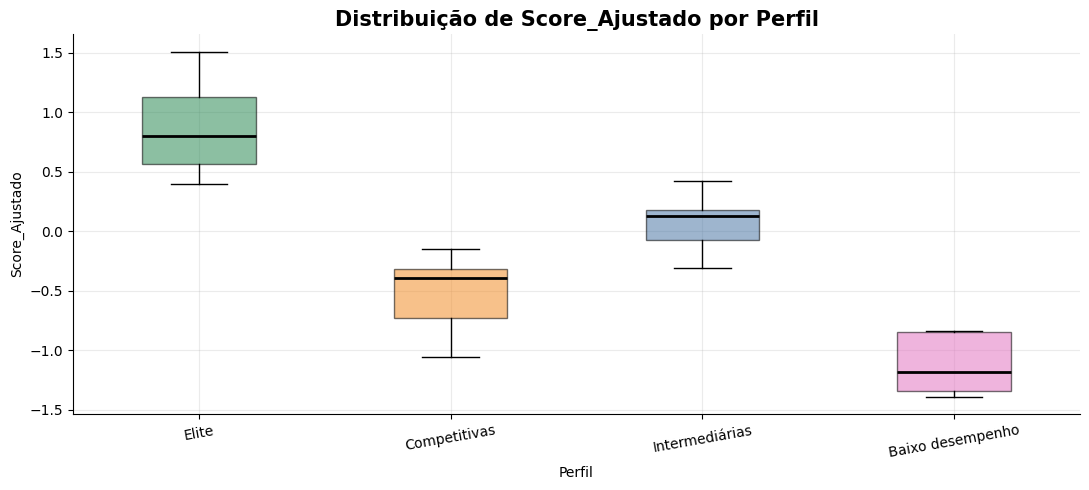

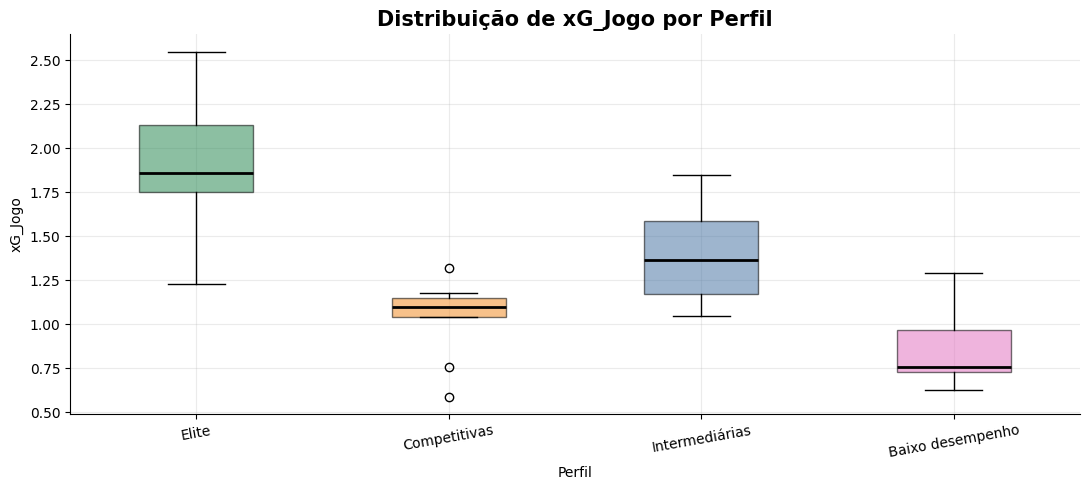

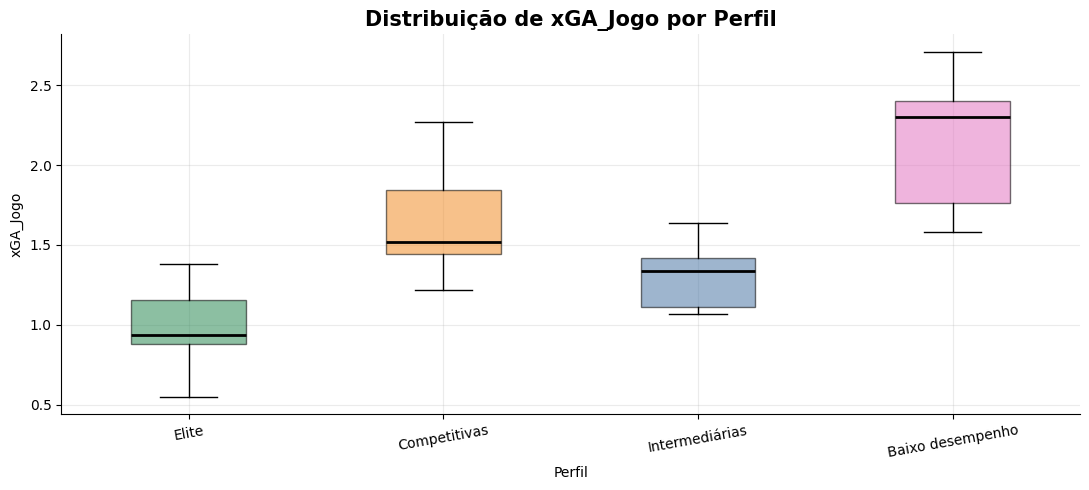

In [20]:
# Boxplots por perfil

variaveis_boxplot = ["Score_Ajustado", "xG_Jogo", "xGA_Jogo"]
ordem_perfis = ["Elite", "Competitivas", "Intermediárias", "Baixo desempenho"]
cores_perfis = {
    "Elite": "#2E8B57",
    "Competitivas": "#F28E2B",
    "Intermediárias": "#4E79A7",
    "Baixo desempenho": "#E377C2"
}

for variavel in variaveis_boxplot:
    fig, ax = plt.subplots(figsize=(11, 5))
    dados = [df_modelo.loc[df_modelo["Perfil"] == p, variavel] for p in ordem_perfis]
    bp = ax.boxplot(dados, labels=ordem_perfis, patch_artist=True, medianprops=dict(color="black", linewidth=2))

    for patch, perfil in zip(bp["boxes"], ordem_perfis):
        patch.set_facecolor(cores_perfis[perfil])
        patch.set_alpha(0.55)

    ax.set_title(f"Distribuição de {variavel} por Perfil", fontsize=15, weight="bold")
    ax.set_xlabel("Perfil")
    ax.set_ylabel(variavel)
    plt.xticks(rotation=10)
    plt.tight_layout()
    plt.show()

## 📈 Visualização com PCA

O PCA projeta as seleções em duas dimensões. A posição horizontal representa, nesta base, um gradiente de desempenho geral. A posição vertical diferencia perfis estatísticos entre equipes.

In [21]:
# PCA e loadings

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X)

df_modelo["PCA1"] = X_pca[:, 0]
df_modelo["PCA2"] = X_pca[:, 1]

loadings = pd.DataFrame(
    pca.components_.T,
    index=features,
    columns=["Componente 1", "Componente 2"]
)

print(f"Variância explicada pelo PCA1: {pca.explained_variance_ratio_[0]:.1%}")
print(f"Variância explicada pelo PCA2: {pca.explained_variance_ratio_[1]:.1%}")
print(f"Variância total explicada: {pca.explained_variance_ratio_.sum():.1%}")

display(loadings.round(3))

Variância explicada pelo PCA1: 75.7%
Variância explicada pelo PCA2: 9.2%
Variância total explicada: 84.8%


,Componente 1,Componente 2
xG_Jogo,0.350,0.250
xGA_Jogo,-0.365,-0.002
xGD_Jogo,0.387,0.137
GF_Jogo,0.296,0.541
GA_Jogo,-0.278,0.763
Score_Ajustado,0.403,0.041
FIFA_Rank,-0.363,0.134
Dif_Selecao_Adversarios,0.369,-0.154


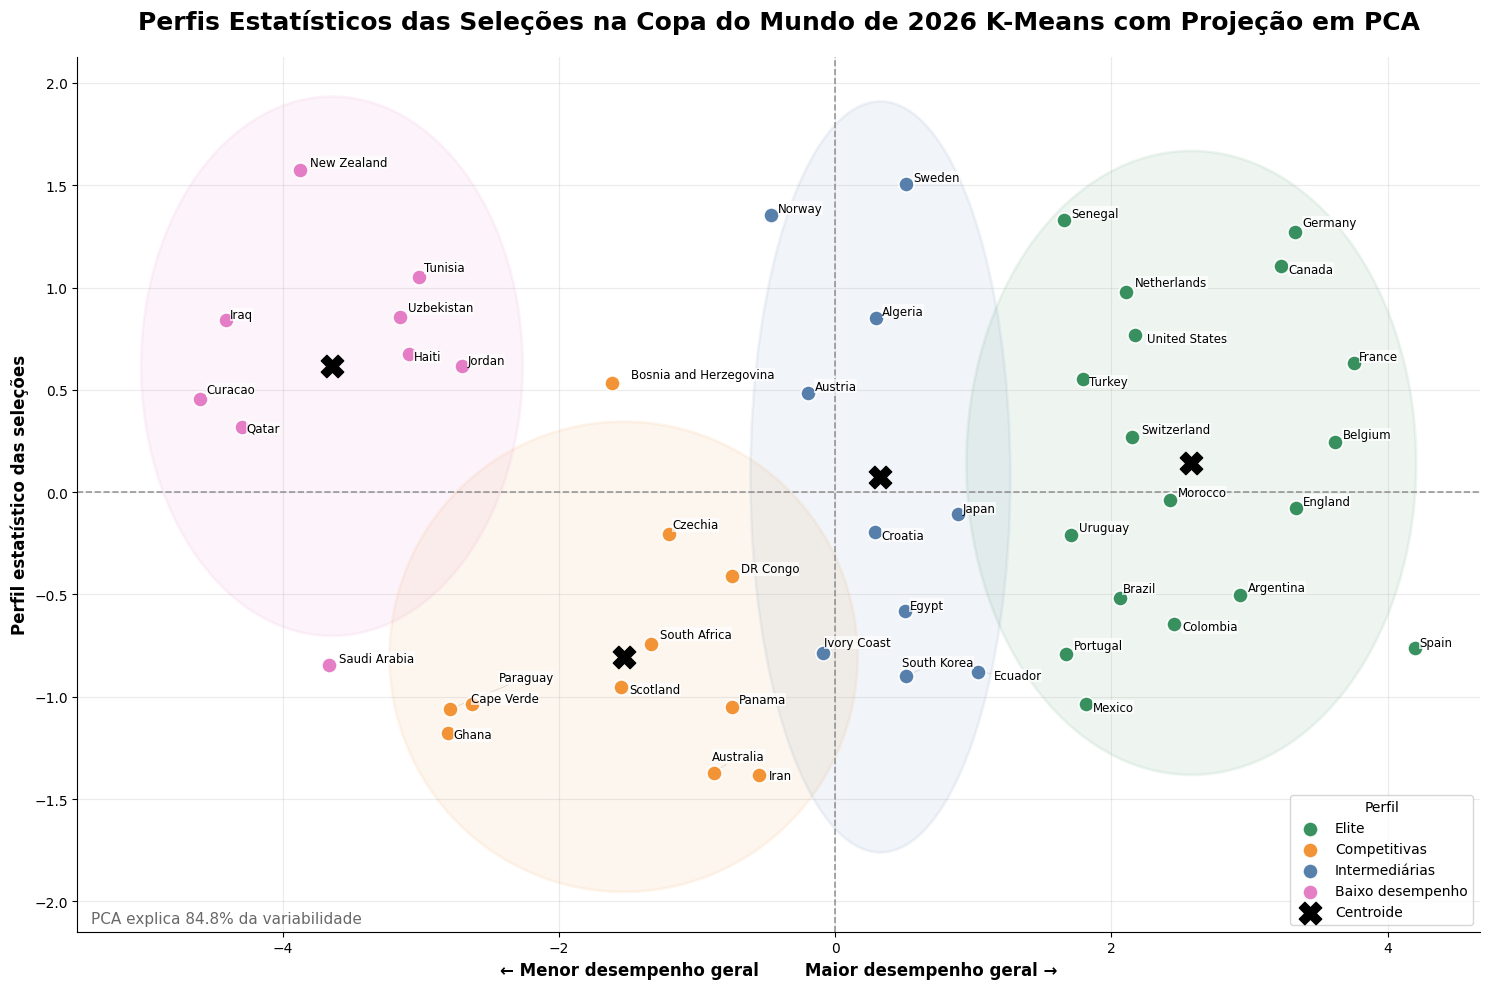

In [23]:
# Gráfico profissional dos clusters com PCA

fig, ax = plt.subplots(figsize=(15, 10))

for perfil in ordem_perfis:
    dados = df_modelo[df_modelo["Perfil"] == perfil]
    cor = cores_perfis[perfil]

    ax.scatter(
        dados["PCA1"], dados["PCA2"],
        s=120,
        color=cor,
        edgecolor="white",
        linewidth=1.2,
        alpha=0.95,
        label=perfil,
        zorder=3
    )

    if len(dados) > 2:
        ellipse = Ellipse(
            (dados["PCA1"].mean(), dados["PCA2"].mean()),
            width=max(dados["PCA1"].std() * 4, 0.2),
            height=max(dados["PCA2"].std() * 4, 0.2),
            edgecolor=cor,
            facecolor=cor,
            alpha=0.08,
            linewidth=2,
            zorder=1
        )
        ax.add_patch(ellipse)

textos = []
for _, row in df_modelo.iterrows():
    textos.append(
        ax.text(
            row["PCA1"], row["PCA2"], row["Selecao"],
            fontsize=8.5,
            bbox=dict(facecolor="white", edgecolor="none", alpha=0.72, pad=0.15),
            zorder=4
        )
    )

if adjust_text is not None:
    adjust_text(textos, ax=ax, arrowprops=dict(arrowstyle="-", color="gray", lw=0.4, alpha=0.4))

centroides_pca = pca.transform(kmeans.cluster_centers_)
ax.scatter(centroides_pca[:, 0], centroides_pca[:, 1], marker="X", s=260, color="black", label="Centroide", zorder=5)

ax.axhline(0, color="gray", linestyle="--", linewidth=1.2, alpha=0.8)
ax.axvline(0, color="gray", linestyle="--", linewidth=1.2, alpha=0.8)

ax.set_title(
    "Perfis Estatísticos das Seleções na Copa do Mundo de 2026 K-Means com Projeção em PCA",
    fontsize=18,
    weight="bold",
    pad=20
)
ax.set_xlabel("← Menor desempenho geral        Maior desempenho geral →", fontsize=12, weight="bold")
ax.set_ylabel("Perfil estatístico das seleções", fontsize=12, weight="bold")
ax.text(0.01, 0.01, f"PCA explica {pca.explained_variance_ratio_.sum():.1%} da variabilidade", transform=ax.transAxes, fontsize=11, color="dimgray")

ax.legend(title="Perfil", frameon=True, loc="best")
plt.tight_layout()
plt.show()

## 🕸️ Rede de similaridade

A rede conecta seleções estatisticamente parecidas. A espessura da ligação indica similaridade, a cor indica o perfil e o tamanho do nó representa o Score Ajustado.

In [24]:
# Matriz de similaridade

similaridade = cosine_similarity(X)
matriz_sim = pd.DataFrame(similaridade, index=df_modelo["Selecao"], columns=df_modelo["Selecao"])

display(matriz_sim.round(2).head())

Selecao,Mexico,South Africa,South Korea,Czechia,Switzerland,Canada,Bosnia and Herzegovina,Qatar,Brazil,Morocco,Scotland,Haiti,United States,Australia,Paraguay,Turkey,Germany,Ivory Coast,Ecuador,Curacao,Netherlands,Japan,Sweden,Tunisia,Belgium,Egypt,Iran,New Zealand,Spain,Cape Verde,Uruguay,Saudi Arabia,France,Norway,Senegal,Iraq,Argentina,Austria,Algeria,Jordan,Colombia,Portugal,DR Congo,Uzbekistan,England,Croatia,Ghana,Panama
Selecao,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
Mexico,1.000,-0.380,0.520,-0.690,0.740,0.490,-0.610,-0.750,0.860,0.780,-0.480,-0.780,0.660,-0.060,-0.510,0.070,0.580,0.430,0.400,-0.870,0.540,0.830,-0.130,-0.780,0.560,0.500,-0.020,-0.910,0.770,-0.520,0.520,-0.660,0.750,-0.390,0.320,-0.840,0.930,-0.040,-0.120,-0.800,0.690,0.860,-0.140,-0.810,0.710,0.440,-0.350,-0.180
South Africa,-0.380,1.000,0.110,0.670,-0.730,-0.490,0.690,0.410,-0.720,-0.760,0.820,0.800,-0.740,0.510,0.570,-0.390,-0.820,0.480,-0.130,0.660,-0.890,-0.520,-0.300,0.360,-0.640,-0.040,0.160,0.550,-0.570,0.880,-0.460,0.710,-0.780,-0.270,-0.850,0.480,-0.670,-0.330,-0.380,0.700,-0.440,-0.650,0.870,0.450,-0.700,-0.550,0.930,0.670
South Korea,0.520,0.110,1.000,0.040,0.230,0.190,-0.530,-0.500,0.240,0.420,0.150,-0.320,0.110,0.240,-0.290,0.310,0.010,0.330,0.730,-0.470,-0.250,0.080,-0.350,-0.350,0.340,0.430,0.170,-0.670,0.580,-0.230,0.710,-0.320,0.150,-0.910,-0.190,-0.430,0.350,-0.460,-0.020,-0.410,0.620,0.320,0.020,-0.380,0.430,0.130,-0.080,0.670
Czechia,-0.690,0.670,0.040,1.000,-0.920,-0.820,0.580,0.790,-0.850,-0.810,0.890,0.780,-0.900,0.540,0.730,-0.430,-0.920,0.030,-0.310,0.830,-0.900,-0.650,-0.380,0.860,-0.810,-0.490,0.310,0.660,-0.750,0.650,-0.470,0.820,-0.940,-0.100,-0.800,0.880,-0.780,0.050,-0.110,0.820,-0.700,-0.740,0.430,0.880,-0.820,-0.080,0.670,0.720
Switzerland,0.740,-0.730,0.230,-0.920,1.000,0.880,-0.720,-0.870,0.860,0.960,-0.900,-0.840,0.950,-0.610,-0.890,0.570,0.970,-0.170,0.460,-0.940,0.840,0.620,0.370,-0.830,0.920,0.430,-0.370,-0.820,0.920,-0.850,0.730,-0.960,0.990,-0.140,0.820,-0.930,0.880,-0.110,0.270,-0.910,0.830,0.760,-0.580,-0.880,0.960,0.200,-0.800,-0.550


In [25]:
# Construção da rede de similaridade

limiar = 0.88
G = nx.Graph()

for _, row in df_modelo.iterrows():
    G.add_node(
        row["Selecao"],
        perfil=row["Perfil"],
        score=row["Score_Ajustado"]
    )

selecoes = df_modelo["Selecao"].tolist()

for i in range(len(selecoes)):
    for j in range(i + 1, len(selecoes)):
        sim = matriz_sim.iloc[i, j]
        if sim >= limiar:
            G.add_edge(selecoes[i], selecoes[j], weight=sim)

print(f"Nós: {G.number_of_nodes()}")
print(f"Conexões: {G.number_of_edges()}")

Nós: 48
Conexões: 71


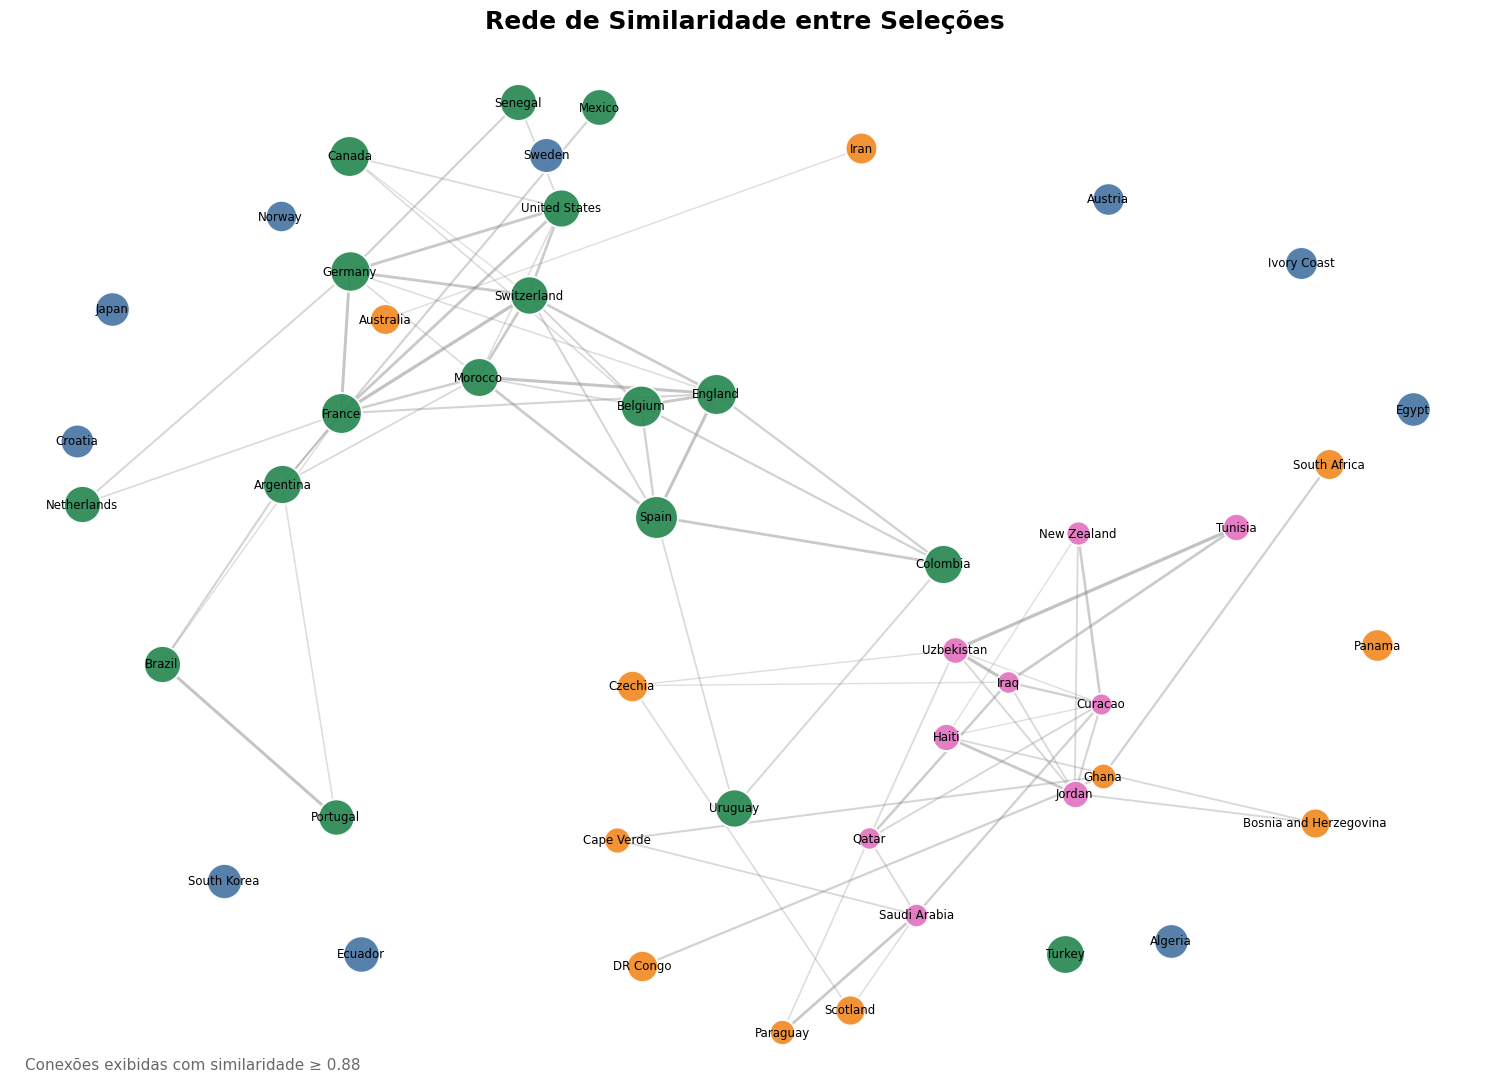

In [26]:
# Visualização da rede

pos = nx.spring_layout(G, seed=42, k=0.8)

fig, ax = plt.subplots(figsize=(15, 11))

# Arestas
for u, v, data in G.edges(data=True):
    x0, y0 = pos[u]
    x1, y1 = pos[v]
    peso = data["weight"]
    ax.plot([x0, x1], [y0, y1], color="gray", alpha=0.25 + (peso - limiar) * 2, linewidth=1 + (peso - limiar) * 12, zorder=1)

# Nós
scores = np.array([G.nodes[n]["score"] for n in G.nodes()])
score_norm = MinMaxScaler(feature_range=(250, 950)).fit_transform(scores.reshape(-1, 1)).ravel()

for idx, node in enumerate(G.nodes()):
    x, y = pos[node]
    perfil = G.nodes[node]["perfil"]
    ax.scatter(x, y, s=score_norm[idx], color=cores_perfis[perfil], edgecolor="white", linewidth=1.4, alpha=0.95, zorder=3)
    ax.text(x, y, node, fontsize=8.5, ha="center", va="center", zorder=4)

ax.set_title("Rede de Similaridade entre Seleções", fontsize=18, weight="bold", pad=20)
ax.text(0.01, 0.01, f"Conexões exibidas com similaridade ≥ {limiar:.2f}", transform=ax.transAxes, fontsize=11, color="dimgray")
ax.axis("off")
plt.tight_layout()
plt.show()

In [27]:
# Seleções mais parecidas

def selecoes_mais_parecidas(selecao, top_n=5):
    if selecao not in matriz_sim.index:
        return "Seleção não encontrada."

    resultado = (
        matriz_sim[selecao]
        .drop(selecao)
        .sort_values(ascending=False)
        .head(top_n)
        .reset_index()
    )
    resultado.columns = ["Seleção", "Similaridade"]
    resultado["Similaridade"] = (resultado["Similaridade"] * 100).round(1)
    return resultado

# Exemplo
selecao_exemplo = "Brazil" if "Brazil" in matriz_sim.index else df_modelo["Selecao"].iloc[0]
selecoes_mais_parecidas(selecao_exemplo)

,Seleção,Similaridade
0,Portugal,98.000
1,Argentina,92.400
2,France,88.400
3,Morocco,87.400
4,Switzerland,86.100


## 🕸️ Radar das seleções de elite

O radar compara as melhores seleções em múltiplos indicadores normalizados. Para defesa, o eixo foi invertido: menor xGA vira melhor nota defensiva.

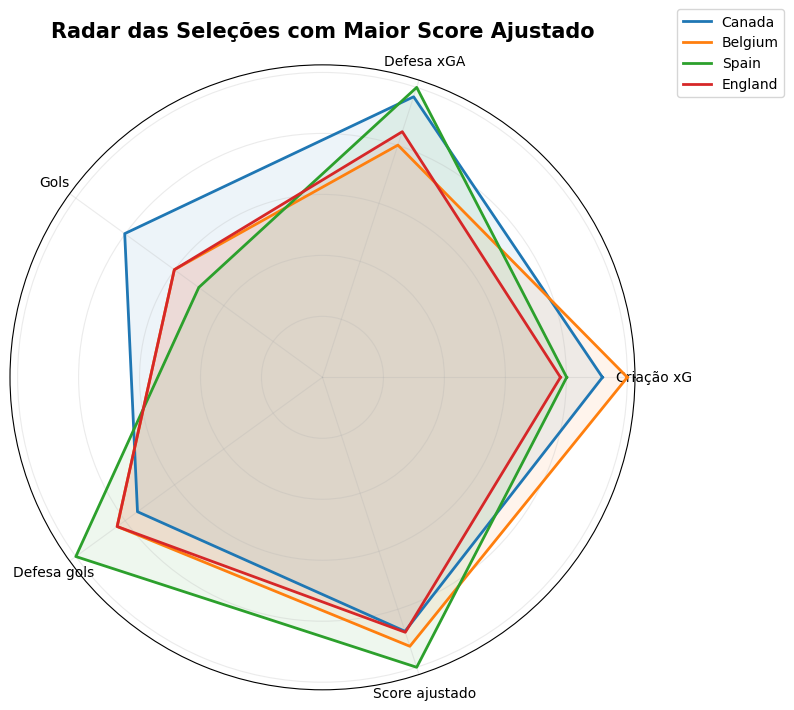

In [28]:
# Radar das quatro melhores seleções

top4 = df_modelo.sort_values("Score_Ajustado", ascending=False).head(4).copy()

radar_base = df_modelo[["Selecao", "xG_Jogo", "xGA_Jogo", "GF_Jogo", "GA_Jogo", "Score_Ajustado"]].copy()
radar_base["Defesa_xGA"] = -radar_base["xGA_Jogo"]
radar_base["Defesa_GA"] = -radar_base["GA_Jogo"]

radar_cols = ["xG_Jogo", "Defesa_xGA", "GF_Jogo", "Defesa_GA", "Score_Ajustado"]
radar_labels = ["Criação xG", "Defesa xGA", "Gols", "Defesa gols", "Score ajustado"]

mm = MinMaxScaler()
radar_scaled = pd.DataFrame(mm.fit_transform(radar_base[radar_cols]), columns=radar_cols)
radar_scaled["Selecao"] = radar_base["Selecao"].values

radar_top = radar_scaled[radar_scaled["Selecao"].isin(top4["Selecao"])]

angles = np.linspace(0, 2 * np.pi, len(radar_cols), endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))

for _, row in radar_top.iterrows():
    values = row[radar_cols].tolist()
    values += values[:1]
    ax.plot(angles, values, linewidth=2, label=row["Selecao"])
    ax.fill(angles, values, alpha=0.08)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(radar_labels)
ax.set_yticklabels([])
ax.set_title("Radar das Seleções com Maior Score Ajustado", fontsize=15, weight="bold", pad=20)
ax.legend(loc="upper right", bbox_to_anchor=(1.25, 1.1))
plt.tight_layout()
plt.show()

## 🎯 Predição da classificação

Treinamos uma Random Forest para estimar a probabilidade de classificação. Como a base tem apenas 48 seleções, o resultado deve ser lido como exercício analítico, não como previsão definitiva.

In [29]:
# Modelo preditivo

y = df_modelo["Classificado_Flag"].astype(int)
X_pred = X.copy()

X_train, X_test, y_train, y_test = train_test_split(
    X_pred,
    y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

modelo_rf = RandomForestClassifier(
    n_estimators=500,
    max_depth=4,
    random_state=42,
    class_weight="balanced"
)

modelo_rf.fit(X_train, y_train)
y_pred = modelo_rf.predict(X_test)

print(classification_report(y_test, y_pred, target_names=["Não classificado", "Classificado"]))

                  precision    recall  f1-score   support

Não classificado       0.75      0.75      0.75         4
    Classificado       0.88      0.88      0.88         8

        accuracy                           0.83        12
       macro avg       0.81      0.81      0.81        12
    weighted avg       0.83      0.83      0.83        12



In [30]:
# Probabilidades de classificação

probs = modelo_rf.predict_proba(X_pred)[:, 1]
df_modelo["Prob_Classificacao"] = probs

ranking_prob = (
    df_modelo[["Selecao", "Perfil", "Classificado", "Prob_Classificacao"]]
    .sort_values("Prob_Classificacao", ascending=False)
    .reset_index(drop=True)
)
ranking_prob["Prob_Classificacao_%"] = (ranking_prob["Prob_Classificacao"] * 100).round(1)

display(ranking_prob.head(20))

,Selecao,Perfil,Classificado,Prob_Classificacao,Prob_Classificacao_%
0,France,Elite,Sim,1.000,100.000
1,Spain,Elite,Sim,1.000,100.000
2,United States,Elite,Sim,0.998,99.800
3,Morocco,Elite,Sim,0.997,99.700
4,Germany,Elite,Sim,0.997,99.700
5,England,Elite,Sim,0.996,99.600
6,Switzerland,Elite,Sim,0.987,98.700
7,Netherlands,Elite,Sim,0.984,98.400
8,Brazil,Elite,Sim,0.974,97.400
9,Colombia,Elite,Sim,0.971,97.100


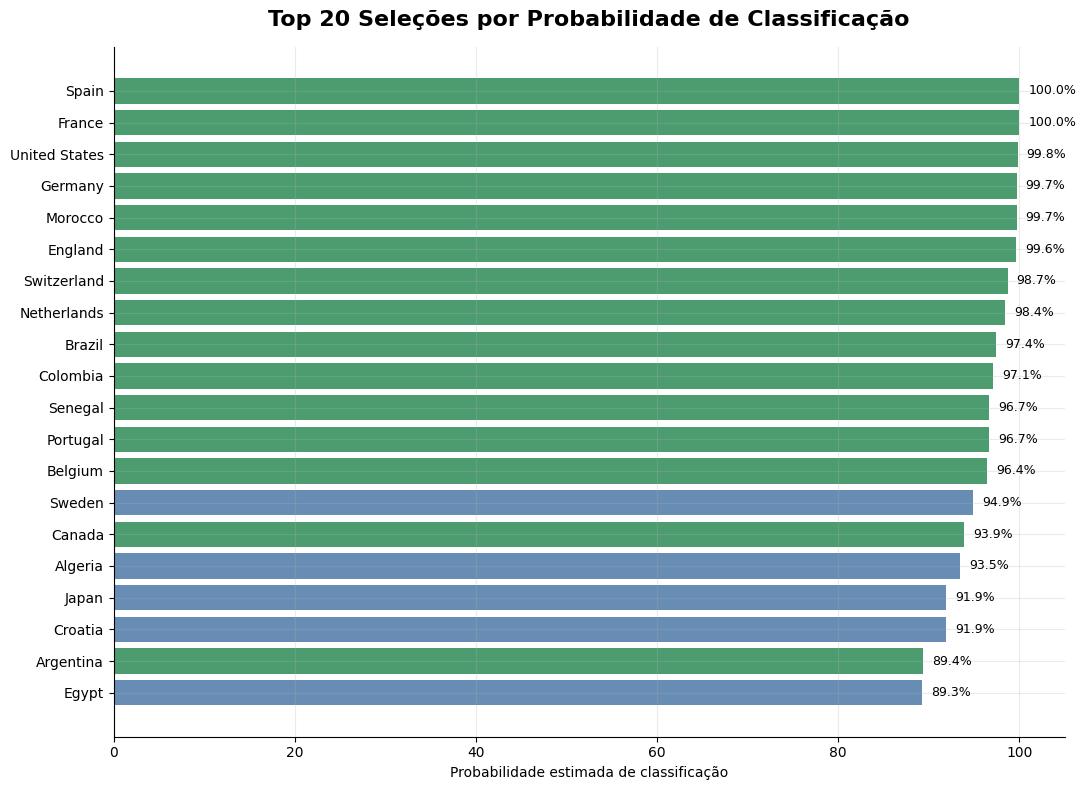

In [31]:
# Gráfico de probabilidade de classificação

top_prob = ranking_prob.head(20).sort_values("Prob_Classificacao_%")

fig, ax = plt.subplots(figsize=(11, 8))
cores_barras = [cores_perfis[p] for p in top_prob["Perfil"]]

ax.barh(top_prob["Selecao"], top_prob["Prob_Classificacao_%"], color=cores_barras, alpha=0.85)

for i, valor in enumerate(top_prob["Prob_Classificacao_%"]):
    ax.text(valor + 1, i, f"{valor:.1f}%", va="center", fontsize=9)

ax.set_xlim(0, 105)
ax.set_xlabel("Probabilidade estimada de classificação")
ax.set_title("Top 20 Seleções por Probabilidade de Classificação", fontsize=16, weight="bold", pad=15)
plt.tight_layout()
plt.show()

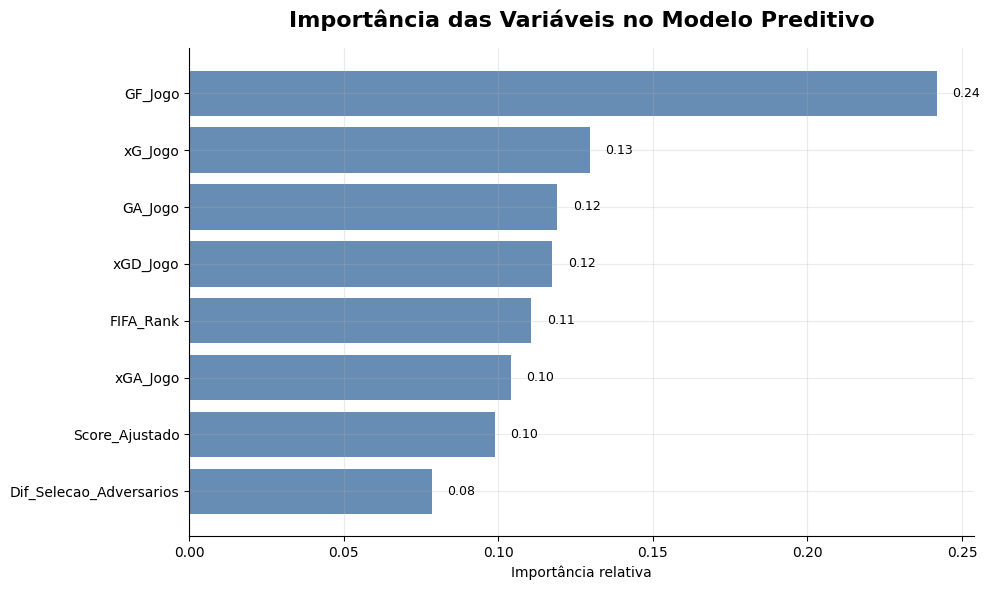

In [32]:
# Importância das variáveis

importancia = pd.DataFrame({
    "Variável": features,
    "Importância": modelo_rf.feature_importances_
}).sort_values("Importância", ascending=True)

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(importancia["Variável"], importancia["Importância"], color="#4E79A7", alpha=0.85)

for i, valor in enumerate(importancia["Importância"]):
    ax.text(valor + 0.005, i, f"{valor:.2f}", va="center", fontsize=9)

ax.set_title("Importância das Variáveis no Modelo Preditivo", fontsize=16, weight="bold", pad=15)
ax.set_xlabel("Importância relativa")
plt.tight_layout()
plt.show()

## 🔍 Análise de Mérito: processo × resultado

A predição da seção anterior identificava quem classificou — mas isso já era conhecido. Esta seção responde uma pergunta mais honesta: **a classificação foi merecida?**

Usamos o **Score Ajustado** como proxy de qualidade do processo e cruzamos com o resultado real. Isso gera quatro quadrantes:

- ✅ **Merecida**: processo acima da média + classificou
- 🍀 **Com sorte**: processo abaixo da média + classificou
- ❌ **Injustiçada**: processo acima da média + foi eliminada
- ⚫ **Esperada**: processo abaixo da média + foi eliminada

In [ ]:
# Classificação de mérito

def classificar_merito(row):
    s, cl = row['Score_Ajustado'], row['Classificado_Flag'] == 1
    if s >= 0 and cl:  return 'Merecida'
    if s < 0  and cl:  return 'Com sorte'
    if s >= 0 and not cl: return 'Injustiçada'
    return 'Esperada'

df_modelo['Merito'] = df_modelo.apply(classificar_merito, axis=1)

print('Distribuição por quadrante:')
print(df_modelo['Merito'].value_counts())

print('\n🍀 Classificadas com menor score (sorte):')
print(df_modelo[df_modelo['Merito']=='Com sorte']
      [['Selecao','Score_Ajustado']].sort_values('Score_Ajustado').head(5).to_string(index=False))

print('\n❌ Eliminadas com maior score (azar):')
print(df_modelo[df_modelo['Merito']=='Injustiçada']
      [['Selecao','Score_Ajustado']].sort_values('Score_Ajustado', ascending=False).to_string(index=False))

In [ ]:
# Gráfico scatter: processo × resultado

import matplotlib.patches as mpatches

CORES_MERITO = {'Merecida':'#16a34a','Com sorte':'#f59e0b',
                'Injustiçada':'#e11d48','Esperada':'#94a3b8'}

np.random.seed(42)
df_modelo['jitter'] = df_modelo['Classificado_Flag'] + np.random.uniform(-0.12, 0.12, len(df_modelo))

fig, ax = plt.subplots(figsize=(14, 7))

# Fundo dos quadrantes
ax.axvspan(-2, 0, ymin=0.5, ymax=1, color='#e11d48', alpha=0.04)
ax.axvspan( 0, 2, ymin=0.5, ymax=1, color='#16a34a', alpha=0.04)
ax.axvspan(-2, 0, ymin=0,   ymax=0.5, color='#94a3b8', alpha=0.04)
ax.axvspan( 0, 2, ymin=0,   ymax=0.5, color='#f59e0b', alpha=0.04)
ax.axvline(0, color='#94a3b8', linestyle='--', lw=1.2, alpha=0.7)
ax.axhline(0.5, color='#94a3b8', linestyle='--', lw=1.2, alpha=0.7)

for merito, cor in CORES_MERITO.items():
    mask = df_modelo['Merito'] == merito
    ax.scatter(df_modelo.loc[mask,'Score_Ajustado'], df_modelo.loc[mask,'jitter'],
               color=cor, edgecolor='white', lw=0.8, s=100, alpha=0.92, label=merito, zorder=3)

destaques = ['Turkey','Uruguay','South Korea','Paraguay','Cape Verde','Ghana']
for _, row in df_modelo[df_modelo['Selecao'].isin(destaques)].iterrows():
    ax.annotate(row['Selecao'], xy=(row['Score_Ajustado'], row['jitter']),
                xytext=(8,4), textcoords='offset points', fontsize=9, fontweight='bold',
                bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.8))

ax.text(-1.5, 1.22, '❌ Injustiçada', fontsize=11, color='#e11d48', fontweight='bold')
ax.text( 0.05, 1.22, '✅ Merecida',   fontsize=11, color='#16a34a', fontweight='bold')
ax.text(-1.5, -0.22, '⚫ Esperada',   fontsize=11, color='#94a3b8', fontweight='bold')
ax.text( 0.05, -0.22, '🍀 Com sorte', fontsize=11, color='#f59e0b', fontweight='bold')

ax.set_yticks([0,1])
ax.set_yticklabels(['Eliminada','Classificou'], fontsize=12)
ax.set_xlabel('Score Ajustado (qualidade do processo)', fontsize=12, fontweight='bold')
ax.set_title('Mérito da Classificação — Copa do Mundo 2026\nProcesso × Resultado',
             fontsize=15, fontweight='bold', pad=14)
ax.set_xlim(-1.6, 1.7)
ax.set_ylim(-0.35, 1.35)
ax.legend(title='Quadrante', loc='center right', framealpha=0.9)
plt.tight_layout()
plt.show()

## 🎲 Simulação Monte Carlo do Mata-Mata

### Para leigos

Imagine uma moeda viciada: a probabilidade de cair cara depende da qualidade de cada seleção. O modelo joga essa moeda em cada partida, simula o torneio inteiro 10.000 vezes e conta quantas vezes cada seleção venceu. O resultado é a **probabilidade estimada de título**.

### Método técnico: Monte Carlo + Bradley-Terry

**Monte Carlo** é uma família de algoritmos que usam aleatoriedade repetida para estimar probabilidades. O nome vem do cassino de Monte Carlo — jogar o mesmo jogo muitas vezes converge para as probabilidades reais.

**Bradley-Terry** (1952) é um modelo de ranking por comparação de pares. A probabilidade de vitória segue uma **função logística (sigmoide)**:

$$P(A \text{ vence } B) = \frac{1}{1 + e^{-k \cdot (\text{score}_A - \text{score}_B)}}$$

Onde `k = 1.5` é o parâmetro de sensibilidade:
- Com k=1.5, diferença de +1.0 no score → **~82% de chance de vitória**
- Com k=0 → todas as partidas ficam 50/50 (sorteio puro)

É o mesmo princípio do **sistema Elo** do xadrez e do **ranking FIFA**.

### Limitações
- Score resume apenas 3 jogos da fase de grupos
- Chaveamento é ilustrativo (grupos cruzados, sem times do mesmo grupo no R32)
- Não considera lesões, forma recente nem histórico de confrontos diretos

In [ ]:
# Simulação Monte Carlo — Bradley-Terry

from scipy.special import expit  # sigmoide: 1/(1+e^-x)

K = 1.5       # sensibilidade do modelo
N = 10_000    # número de simulações
np.random.seed(42)

# 32 classificados com seus Scores Ajustados
scores_32 = {
    'Espanha':1.51,'Paraguai':-1.06,'Alemanha':1.07,'Cabo Verde':-0.96,
    'Países Baixos':0.53,'RD Congo':-0.32,'Bélgica':1.30,'Austrália':-0.39,
    'França':1.15,'Gana':-1.02,'Inglaterra':1.16,'Egito':0.13,
    'Colômbia':0.84,'Japão':0.13,'Argentina':0.85,'Noruega':-0.31,
    'Marrocos':0.81,'África do Sul':-0.38,'Canadá':1.15,'Áustria':-0.16,
    'Brasil':0.53,'Bósnia e Herz.':-0.50,'Suíça':0.71,'Costa do Marfim':-0.11,
    'México':0.46,'Croácia':0.02,'Estados Unidos':0.67,'Argélia':0.15,
    'Senegal':0.50,'Equador':0.42,'Portugal':0.40,'Suécia':0.19,
}

# Chaveamento R32 — 16 confrontos (grupos cruzados)
bracket_r32 = [
    ('Espanha','Paraguai'),       ('Alemanha','Cabo Verde'),
    ('Países Baixos','RD Congo'), ('Bélgica','Austrália'),
    ('França','Gana'),            ('Inglaterra','Egito'),
    ('Colômbia','Japão'),         ('Argentina','Noruega'),
    ('Marrocos','África do Sul'), ('Canadá','Áustria'),
    ('Brasil','Bósnia e Herz.'),  ('Suíça','Costa do Marfim'),
    ('México','Croácia'),         ('Estados Unidos','Argélia'),
    ('Senegal','Equador'),        ('Portugal','Suécia'),
]

def p_vitoria(a, b):
    """Probabilidade de 'a' vencer 'b' — Bradley-Terry."""
    return float(expit(K * (scores_32[a] - scores_32[b])))

def simular_rodada(confrontos):
    vencedores = []
    for a, b in confrontos:
        vencedores.append(a if np.random.random() < p_vitoria(a, b) else b)
    return vencedores

def simular_torneio():
    """Simula R32 → oitavas → quartas → semi → final."""
    vivos = simular_rodada(bracket_r32)           # 32 → 16
    for _ in range(4):                            # 16→8→4→2→1
        vivos = simular_rodada(list(zip(vivos[::2], vivos[1::2])))
    return vivos[0]

# Rodar N simulações
contagem = {s: 0 for s in scores_32}
for _ in range(N):
    contagem[simular_torneio()] += 1

df_sim = pd.DataFrame([
    {'Seleção': s, 'Score_Ajustado': scores_32[s], 'P_Titulo_%': round(v/N*100, 1)}
    for s, v in contagem.items()
]).sort_values('P_Titulo_%', ascending=False).reset_index(drop=True)
df_sim.index += 1

print(f'Simulações: {N:,}  |  Parâmetro k: {K}')
display(df_sim.head(20))

In [ ]:
# Gráfico — probabilidade de título

top = df_sim.head(16).sort_values('P_Titulo_%')
cores = ['#16a34a' if s >= 0.5 else '#2563eb' if s >= 0 else '#f59e0b'
         for s in top['Score_Ajustado']]

fig, ax = plt.subplots(figsize=(11, 7))
bars = ax.barh(top['Seleção'], top['P_Titulo_%'], color=cores, alpha=0.85, edgecolor='white')
for bar, val in zip(bars, top['P_Titulo_%']):
    ax.text(val + 0.2, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}%', va='center', fontsize=10, fontweight='bold')

ax.set_xlabel('Probabilidade de ser campeã (%)', fontsize=12)
ax.set_title(f'Monte Carlo + Bradley-Terry — Probabilidade de Título\n'
             f'{N:,} simulações | k={K}', fontsize=14, fontweight='bold', pad=12)
ax.set_xlim(0, top['P_Titulo_%'].max() * 1.18)

patches = [
    mpatches.Patch(color='#16a34a', label='Score ≥ 0.5'),
    mpatches.Patch(color='#2563eb', label='0 ≤ Score < 0.5'),
    mpatches.Patch(color='#f59e0b', label='Score < 0'),
]
ax.legend(handles=patches, loc='lower right', fontsize=9)
plt.tight_layout()
plt.show()

In [ ]:
# Matriz de probabilidades entre os 6 maiores favoritos

top6 = df_sim.head(6)['Seleção'].tolist()
print(f'Probabilidade de vitória (linha vence coluna) | k={K}\n')
print(f"{'':20s}" + ''.join(f'{s:>16s}' for s in top6))
print('-' * (20 + 16*len(top6)))
for a in top6:
    linha = f'{a:20s}'
    for b in top6:
        linha += f"{'  —':>16s}" if a==b else f"{p_vitoria(a,b)*100:>14.1f}%"
    print(linha)

print(f'\nExemplos:')
print(f'  Espanha vs Paraguai : {p_vitoria("Espanha","Paraguai"):.1%}')
print(f'  Argentina vs Brasil : {p_vitoria("Argentina","Brasil"):.1%}')
print(f'  França vs Inglaterra: {p_vitoria("França","Inglaterra"):.1%}')

## 📌 Conclusões

A análise identificou quatro perfis estatísticos. O grupo de **Elite** concentrou as seleções com maior Score Ajustado, melhor produção ofensiva e melhor força relativa.

A análise de **mérito** revelou Turquia e Uruguai como as maiores vítimas da fase de grupos, enquanto Paraguai, Cabo Verde e Gana se classificaram com os processos mais fracos entre os 32.

A **simulação Monte Carlo com Bradley-Terry** projeta Espanha e Bélgica como maiores favoritas, mas o chaveamento cria assimetrias — seleções fortes no mesmo lado do bracket se eliminarão antes da final.

Como a base representa uma fase curta do torneio, todos os modelos devem ser lidos como ferramentas exploratórias, não como previsões definitivas.